# Transformer From Scratch

Based on Neel Nanda's GPT-2 From Scratch

Adapted to use only PyTorch and NumPy (+ HuggingFace for the reference model). Neel's EasyTransformers is great, but it's changed quite a bit!

Did a full write-up here, with an explanation (credit to Neel's videos!) and some additional exploration: https://emma-x1.github.io/writing/transformer-from-scratch

Major adaptations:
- The order is a little different (to me it made more sense to think about embedding before `LayerNorm`), and I tried to explain each layer myself in a way that made sense to me, showing the tensors whenever possible.

(Some of the) Technical changes:
- `model(x)` returns a `CausalLMOutputWithCrossAttentions`, which is a named tuple with `.logits`, `.past_key_values`, `.hidden_states`, `.attentions` - not just logits
- `run_with_cache` gives entries even for sub modules, use `c_attn` for concatenated QKV matrix `[B, T, 3*d_model]` before split
- Attention returns a tuple `(attn_output, present_key_value, attn_weights)`, so `output[0]` is the post-attention residual contribution that gets added back to the stream
- Testing (`load_gpt_2_test`) is quite a bit more involved, Neel's library does a great job simplifying it so there's quite a bit of adaptation here

# Setup, Utilities, etc

In [314]:
%pip install transformers
%pip install fancy_einsum
%pip install einops


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [315]:
import einops # for tensor expressions
from fancy_einsum import einsum 
from dataclasses import dataclass # decorators, to allow us to pass a config around
import torch # classic for all deep learning
import torch.nn as nn 
import numpy as np # for all sorts of math functions
import math
import tqdm.auto as tqdm # to show progress bars :)

In [316]:
#Config object to set params of the model - we copy GPT-2's parameters, but would be interesting to play around with these
@dataclass
class Config:
    d_model: int = 768 # dimensionality of the residual stream
    debug: bool = True # printing tensor shapes for debugging
    layer_norm_epsilon: float = 1e-5 # added in layernorm to prevent division by 0
    d_vocab: int = 50257 # size of our vocabulary 'dictionary' - depends on the tokenizer
    init_range: float = 0.02
    n_ctx: int = 1024 # maximum number of tokens in a sequence, "context window"
    d_head: int = 64 # dimension per attention head (d_model / n_heads)
    d_mlp: int = 3072 # size of the MLP layer (4 * d_model)
    n_heads: int = 12 # number of attention heads
    n_layers: int = 12 # number of transformer blocks
    
cfg = Config()
print(cfg)

Config(d_model=768, debug=True, layer_norm_epsilon=1e-05, d_vocab=50257, init_range=0.02, n_ctx=1024, d_head=64, d_mlp=3072, n_heads=12, n_layers=12)


## Reference Model

Loading the reference GPT-2 model from HuggingFace, used to check and compare against our implementation.

In [317]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(device)
device = "cpu" # hard-code, some operations not yet supported on mps

model_name = "gpt2"  # this is gpt2-small

reference_gpt2 = GPT2LMHeadModel.from_pretrained(model_name)
tokenizer = GPT2Tokenizer.from_pretrained(model_name)

reference_gpt2.eval() # set to inference mode, not training mode

mps


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2SdpaAttention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [318]:
print(reference_gpt2)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2SdpaAttention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)


In [319]:
# helpers

def run_with_cache(model, tokens):
    cache = {}
    hooks = []
    
    def make_hook(name):
        def hook(module, input, output):
            if isinstance(output, torch.Tensor):
                cache[name] = output.detach()
            elif isinstance(output, tuple) and isinstance(output[0], torch.Tensor):
                cache[name] = output[0].detach()
        return hook
    
    for name, module in model.named_modules():
        hooks.append(module.register_forward_hook(make_hook(name)))
        
    with torch.no_grad():
        out = model(tokens, output_attentions=True)
        
    for h in hooks:
        h.remove()
        
    return out.logits, out.attentions, cache

Key:
batch = 1
position = 35
d_model = 768
n_heads = 12
n_layers = 12
d_mlp = 3072 (4 * d_model)
d_head = 64 (d_model / n_heads)

In [320]:
# text to tokens
reference_text = "To be, or not to be. That is the question "
tokens = tokenizer.encode(reference_text, return_tensors="pt").to(device)
print(tokens)
print(tokens.shape) # [batch, position]
print(tokenizer.convert_ids_to_tokens(tokens[0].tolist()))

tensor([[2514,  307,   11,  393,  407,  284,  307,   13, 1320,  318,  262, 1808,
          220]])
torch.Size([1, 13])
['To', 'Ġbe', ',', 'Ġor', 'Ġnot', 'Ġto', 'Ġbe', '.', 'ĠThat', 'Ġis', 'Ġthe', 'Ġquestion', 'Ġ']


In [321]:
# tokens to logits
logits, attention, cache = run_with_cache(reference_gpt2, tokens)
print(logits.shape) # [batch, position]

torch.Size([1, 13, 50257])


In [322]:
# logits to distribution
log_probs = logits.log_softmax(dim=-1)
probs = logits.softmax(dim=-1)
print(log_probs.shape)
print(probs.shape)

torch.Size([1, 13, 50257])
torch.Size([1, 13, 50257])


In [323]:
# distribution to token
last_logits = logits[0, -1]
next_token = last_logits.argmax(dim=-1) # -1 for the last token
print(last_logits)
print(next_token)
print(tokenizer.decode([next_token.item()]))

tensor([-65.8917, -66.7953, -69.4056,  ..., -76.4183, -73.3270, -69.4448])
tensor(1849)
 


In [324]:
# repeat!
next_tokens = torch.cat(
    [tokens, next_token.reshape(1,1)], dim=-1)

with torch.no_grad():
    new_output = reference_gpt2(next_tokens)
    
new_logits = new_output.logits # [batch, position, vocab_size]

print("New input (tokens):", next_tokens)
print(next_tokens.shape)
print("New input (text):", tokenizer.decode(next_tokens[0].tolist()))

print(new_logits.shape)

predicted_token_id = new_logits[0, -1].argmax(-1)
print("Predicted next token:", tokenizer.decode([predicted_token_id.item()]))

New input (tokens): tensor([[2514,  307,   11,  393,  407,  284,  307,   13, 1320,  318,  262, 1808,
          220, 1849]])
torch.Size([1, 14])
New input (text): To be, or not to be. That is the question  
torch.Size([1, 14, 50257])
Predicted next token: of


In [325]:
# Activation Shapes
for activation_name, activation in cache.items():
    if not hasattr(activation, 'shape'):
        continue
    is_block_0 = "transformer.h.0" in activation_name
    is_top_level = "transformer.h" not in activation_name and activation_name != ""
    if is_block_0 or is_top_level: # only first block
        print(activation_name, tuple(activation.shape))

transformer.wte (1, 13, 768)
transformer.wpe (1, 13, 768)
transformer.drop (1, 13, 768)
transformer.h.0.ln_1 (1, 13, 768)
transformer.h.0.attn.c_attn (1, 13, 2304)
transformer.h.0.attn.attn_dropout (1, 12, 13, 13)
transformer.h.0.attn.c_proj (1, 13, 768)
transformer.h.0.attn.resid_dropout (1, 13, 768)
transformer.h.0.attn (1, 13, 768)
transformer.h.0.ln_2 (1, 13, 768)
transformer.h.0.mlp.c_fc (1, 13, 3072)
transformer.h.0.mlp.act (1, 13, 3072)
transformer.h.0.mlp.c_proj (1, 13, 768)
transformer.h.0.mlp.dropout (1, 13, 768)
transformer.h.0.mlp (1, 13, 768)
transformer.h.0 (1, 13, 768)
transformer.ln_f (1, 13, 768)
lm_head (1, 13, 50257)


## Test

In [326]:
# get_corner returns top-left corner of last two dimensions 
def get_corner(tensor, n=3):
    return tensor[..., :n, :n]

In [363]:
# generate tensor of floats
def rand_float_test(cls, shape):
    cfg = Config(debug=True)
    layer = cls(cfg)
    random_input = torch.randn(shape) # standard gaussian
    print("Input shape:", random_input.shape)
    output = layer(random_input)
    print("Output shape:", output.shape)
    print(get_corner(output))
    return output

# generate tensor of ints
def rand_int_test(cls, shape):
    cfg = Config(debug=True)
    layer = cls(cfg)
    random_input = torch.randint(low=0, high=cfg.d_vocab, size=shape) # standard gaussian
    print("Input shape:", random_input.shape)
    output = layer(random_input)
    print("Output shape:", output.shape)
    print(get_corner(output))
    return output

# testing our impl against base model
# load same weights into our impl, then check for same output
def load_gpt2_test(cls, gpt2_layer, input_name, gpt2_layer_output):
    cfg = Config(debug=True)
    layer = cls(cfg)
    
    if hasattr(layer, "load_from_hf"):
        layer.load_from_hf(gpt2_layer)
    else:
        layer.load_state_dict(gpt2_layer.state_dict(), strict=False)
    if isinstance(input_name, str):
        reference_input = cache[input_name]
    else:
        reference_input = input_name
            
    print("Input shape:", reference_input.shape)
    
    output = layer(reference_input) # output is our impl run on the input
    print("Output shape:", output.shape)
    print("Reference output shape:", gpt2_layer_output.shape)
    
    comparison = torch.isclose(output, gpt2_layer_output, atol=1e-4, rtol=1e-3)
    print(f"{comparison.sum()/comparison.numel():.2%} of values are correct")
    return output


# Embedding

- A lookup table from input token to vector
- This is batched - we process `batch` tokens at a time 

Input:
- We take an input `tokens` of dimensions `[batch, n_ctx]`

Embed: 
- Embed applies a weight matrix of dimensions `[d_vocab, d_model]` - a lookup table
    - This is what learning does - it updates the weights, initially initialized randomly, so that it can more closely approximate the data thereby 'learning'

Output:
- Matrix representing the embedded token values of size `[batch, n_ctx, d_model]`

In [393]:
class Embed(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        # nn.Parameter is a tensor, treated as a learnable weight - ie. we'll tune this
        # self.weight is 'syntactic sugar' - we don't do every matrix multiplication since most entries are 0s
        self.W_E = nn.Parameter(torch.randn(cfg.d_vocab, cfg.d_model)) # why 0.02? why not?
        nn.init.normal_(self.W_E, std=self.cfg.init_range) # this relates to initialization theory - a whole fascinating field
    
    def forward(self, tokens):
        # tokens: [batch, n_ctx]
        if cfg.debug: print("Tokens:", tokens.shape)
        embed = self.W_E[tokens, :] # [batch, n_ctx, d_model]
        if cfg.debug: print("Embeddings:", embed.shape)
        return embed
    
    def load_from_hf(self, hf_layer):
        self.W_E.data = hf_layer.weight.data

In [394]:
x = torch.randint(low=0, high=cfg.d_vocab, size=[2,4])
reference_output = reference_gpt2.transformer.wte(x)
load_gpt2_test(Embed, reference_gpt2.transformer.wte, x, reference_output)

Input shape: torch.Size([2, 4])
Tokens: torch.Size([2, 4])
Embeddings: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])
Reference output shape: torch.Size([2, 4, 768])
100.00% of values are correct


tensor([[[ 0.2048, -0.1030,  0.1140,  ...,  0.3998,  0.0062,  0.0778],
         [ 0.1382, -0.0524,  0.0735,  ...,  0.1227, -0.0055,  0.0730],
         [-0.1125,  0.0153,  0.0132,  ...,  0.0590, -0.1619,  0.1930],
         [-0.0741, -0.1624,  0.1870,  ...,  0.2443,  0.0644, -0.0947]],

        [[-0.0175,  0.0656,  0.2091,  ..., -0.2124,  0.0240,  0.0809],
         [-0.1387, -0.0557, -0.0405,  ...,  0.1811, -0.0548,  0.0751],
         [-0.0822, -0.0507, -0.0868,  ..., -0.1060, -0.3442,  0.2954],
         [ 0.0680,  0.0453,  0.0371,  ...,  0.1746,  0.0074, -0.0038]]],
       grad_fn=<IndexBackward0>)

# Postitional Embedding
- We add information about the position of each token. 
- Later, we'll add this to the `Embed` matrix. Note that we're working in such a high dimensionality that simply adding the matrices just *works* without too much interference

Input: 
- Same tokens from `Embed` of size `[batch, n_ctx]`

Positional Embedding:
- We apply a lookup table of shape `[n_ctx, d_model]`

Output:
- Matrix of size `[batch, position, d_model]`

In [330]:
class PosEmbed(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        # torch.empty allocates the memory but doesn't initialize it - faster than zeros or randn, since we're initializing weights on the next line
        self.weight  = nn.Parameter(torch.empty((cfg.n_ctx, cfg.d_model)))
        nn.init.normal_(self.weight, std=self.cfg.init_range)
        
    def forward(self, tokens):
        # tokens: [batch, position]
        if cfg.debug: print("Tokens:", tokens.shape)
        # self.weight[:tokens.size(1), :] applies weight based on the position of the word (as opposed to the token value)
        pos_embed = self.weight[:tokens.size(1), :] # [position, d_model]
        # einops.repeat repeats this positional embedding across all rows
        # the equivalent without einops would be: pos_embed = pos_embed.unsqueeze(0).expand(tokens.size(0), -1, -1)
        pos_embed = einops.repeat(pos_embed, "position d_model -> batch position d_model", batch=tokens.size(0))
        if cfg.debug: print("Positional Embeddings:", pos_embed.shape)
        return pos_embed

In [357]:
def test_pos_embed(): # need specialized tests - API contracts are funky
    cfg = Config()
    cfg.debug = False
    
    # 1. Initialize our layer
    my_pos_embed = PosEmbed(cfg)
    
    # 2. Get the reference layer
    ref_model = reference_gpt2 # assuming this is your HF model
    ref_layer = ref_model.transformer.wpe
    
    # 3. Manually load weights
    my_pos_embed.weight.data = ref_layer.weight.data.clone()
    
    # 4. Create a 2D input (Batch=2, Seq=4)
    test_tokens = torch.zeros((2, 4), dtype=torch.long) 
    
    # 5. Run our implementation
    my_output = my_pos_embed(test_tokens)
    
    # 6. Run reference implementation
    indices = torch.arange(4).unsqueeze(0).repeat(2, 1) # [[0,1,2,3], [0,1,2,3]]
    ref_output = ref_layer(indices)
    
    # 7. Compare
    check = torch.allclose(my_output, ref_output, atol=1e-5)
    print(f"Match: {check}")
    if not check:
        print("Our head:", my_output[0, 0, :5])
        print("Ref head:", ref_output[0, 0, :5])

test_pos_embed()

Tokens: torch.Size([2, 4])
Positional Embeddings: torch.Size([2, 4, 768])
Match: True


# LayerNorm

- Applied at the start of each layer (MLP, attention)
- Normalizing function, taking an input vector and transforming it to have mean = 0 and variance = 1
- Also applies some non-linear scaling with the learned weights
- Neel describes this as an area where pretty cool math takes place - elementwise scaling and translation 

Input:
- `residual` is the embedded tokens, of dimensionality `[batch, position, d_model]`

LayerNorm:
- We have a `weight` - a tensor of dimension `[d_model]` consisting of all ones
- We have a `bias` - a tensor of dimension `[d_model]` consisting of all zeros

Output:
- Matrix of size `[batch, position, d_model]`

In [395]:
class LayerNorm(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(cfg.d_model)) # norm by default = 1
        self.bias = nn.Parameter(torch.zeros(cfg.d_model)) # mean by default = 0
        
    def forward(self, residual):
        # residual: [batch, position, d_model]
        if cfg.debug: print("Residual:", residual.shape)
        # einops.reduce collapses the dimension, default by averaging
        residual = residual - einops.reduce(residual, "batch position d_model -> batch position 1", "mean")
        # calculate variance and square root, then add epsilon to ensure non-zero
        #   variance: sum of squares / n
        scale = (einops.reduce(residual.pow(2), "batch position d_model -> batch position 1", "mean") + cfg.layer_norm_epsilon).sqrt()
        residual = residual / scale
        normalized = residual * self.weight + self.bias
        if cfg.debug: print("Normalized:", residual.shape)
        return normalized

In [396]:
x = rand_float_test(LayerNorm, [2, 4, 768])
reference_output = reference_gpt2.transformer.h[0].ln_1(x)
load_gpt2_test(LayerNorm, reference_gpt2.transformer.h[0].ln_1, x, reference_output)

Input shape: torch.Size([2, 4, 768])
Residual: torch.Size([2, 4, 768])
Normalized: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])
tensor([[[ 0.7658, -1.6141, -1.3607],
         [-0.7887, -1.2264, -0.5755],
         [-0.5151, -0.7572,  0.3087]],

        [[-0.2079,  0.5941, -1.3896],
         [ 0.9527,  0.3241,  0.3596],
         [-0.7874,  1.8922, -0.8468]]], grad_fn=<SliceBackward0>)
Input shape: torch.Size([2, 4, 768])
Residual: torch.Size([2, 4, 768])
Normalized: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])
Reference output shape: torch.Size([2, 4, 768])
100.00% of values are correct


tensor([[[ 0.1673, -0.2665, -0.2728,  ..., -0.3433,  0.2926,  0.0545],
         [-0.1797, -0.1960, -0.1523,  ..., -0.0240,  0.0573,  0.2965],
         [-0.1187, -0.1106, -0.0167,  ...,  0.1270, -0.1989, -0.0702],
         [ 0.2069,  0.2177,  0.0763,  ..., -0.0514, -0.0686, -0.0630]],

        [[-0.0501,  0.1353, -0.2772,  ..., -0.3420, -0.2212, -0.1758],
         [ 0.2090,  0.0862, -0.0089,  ..., -0.0018,  0.2035, -0.4109],
         [-0.1794,  0.3715, -0.1940,  ...,  0.4097, -0.1095, -0.2676],
         [-0.0594, -0.1618, -0.2436,  ...,  0.2369,  0.0606,  0.3175]]],
       grad_fn=<AddBackward0>)

# Attention
- This is the only step that moves information from a prior position in the sequence to the current one
- We parallelize this - we do this for each token for all prefix token strings
- We compute n_heads multiple attention matrices for each sequence - essentially capturing different types of dependencies between words

Input:
- The residual stream of tokens, `normalized_resid_pre` of size `[batch, position, d_model]`

Attention:
- Query, key, value weights and biases, as well as an output weight and bias. All weights are of size `[n_heads, d_model, d_head]`. Biases for query, key, value are of size `[n_heads, d_head]`. Bias for output is of size `[d_model]`.
- There's also a register buffer - it holds the causal attention mask, essentially preventing the model from looking ahead when training.

Output:
- An attention pattern, which is added back to the residual stream for output of size `[batch, position, d_model]`


* Step 1: Produce attention pattern. For each destination token, produce a probability distribution over all previous tokens including itself
    * Linear map from input -> query, key shape [batch, position, head_index, d_head]
    * Dot product every pair of queries and keys to get attn_scores [batch, head_index, query_pos, key_pos] (query = dest, key = source)
    * Scale and mask attn_scores to make it lower triangular (remember when they said linear algebra would be useful?)
    * Softmax row-wise to get prob distribution along each key_pos dimension as attention pattern
* Step 2: Move info from source token to destination token using attention pattern (move via applying linear map)
    * Linear map from input -> value [batch, key_pos, head_index, d_head]
    * Mix along key_pos with attention pattern to get intermediate z [batch, query_pos, head_index, d_head]
    * Map to output [batch, position, d_model] (where position = query_pos summed over all heads)


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
torch.Size([1, 12, 13, 13])


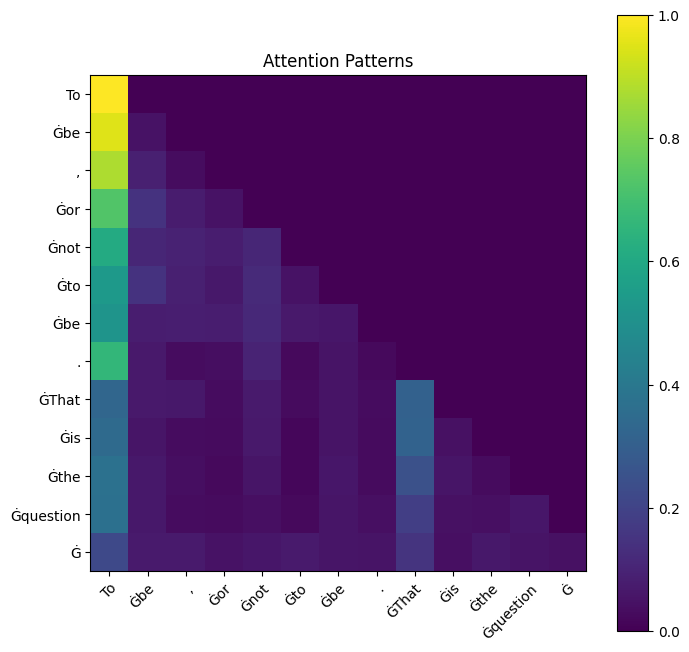

In [334]:
# diy with matplotlib + numpy! recall - self heads vs others. diagonal patterns.
%pip install matplotlib
import matplotlib.pyplot as plt
import numpy as np

# this is extensible to other types of attention (not just self attention)
def plot_attention_matrix(attention_mask, src_tokens, tgt_tokens):
    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(attention_mask, cmap='viridis')

    # add labels for tokens
    ax.set_xticks(np.arange(len(src_tokens)))
    ax.set_yticks(np.arange(len(tgt_tokens)))
    ax.set_xticklabels(src_tokens)
    ax.set_yticklabels(tgt_tokens)

    # tick labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    plt.colorbar(im)
    plt.title("Attention Patterns")
    plt.show()

# print attention 
print(attention[0].shape)

plot_attention_matrix(src_tokens=tokenizer.convert_ids_to_tokens(tokens[0].tolist()), 
                      tgt_tokens=tokenizer.convert_ids_to_tokens(tokens[0].tolist()), 
                      attention_mask=attention[0][0, 0, :, :])

In [335]:
class Attention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_Q = nn.Parameter(torch.empty((cfg.n_heads, cfg.d_model, cfg.d_head)))
        nn.init.normal_(self.W_Q, std=self.cfg.init_range) # _ suffix means in-place method
        self.b_Q = nn.Parameter(torch.zeros((cfg.n_heads, cfg.d_head)))
        self.W_K = nn.Parameter(torch.empty((cfg.n_heads, cfg.d_model, cfg.d_head)))
        nn.init.normal_(self.W_K, std=self.cfg.init_range)
        self.b_K = nn.Parameter(torch.zeros((cfg.n_heads, cfg.d_head)))
        self.W_V = nn.Parameter(torch.empty((cfg.n_heads, cfg.d_model, cfg.d_head))) # make tuple
        nn.init.normal_(self.W_V, std=self.cfg.init_range)
        self.b_V = nn.Parameter(torch.zeros((cfg.n_heads, cfg.d_head)))
        
        self.W_O = nn.Parameter(torch.empty((cfg.n_heads, cfg.d_head, cfg.d_model)))
        nn.init.normal_(self.W_O, std=self.cfg.init_range)
        self.b_O = nn.Parameter(torch.zeros((cfg.d_model)))
        
        # causal mask fill value
        self.register_buffer("IGNORE", torch.tensor(-1e5, dtype=torch.float32, device="cpu"))
        
    def forward(self, normalized_resid_pre): # input is normalized residual
        # normalized_resid_pre: [batch, position, d_model]
        if cfg.debug: print("Normalized Residual (Pre):", normalized_resid_pre.shape)
        
        # query, key - apply the Q and K weights/biases to the residual stream to get matrices of 
        # q: [batch, position n_heads, d_head]
        # v: [batch, key_pos, n_heads, d_head]
        # note einsums are linear maps
        # even though b_Q and b_K are of lower dimension, the trailing dimensions match
        q = einsum("batch position d_model, n_heads d_model d_head -> batch position n_heads d_head", normalized_resid_pre, self.W_Q) + self.b_Q
        k = einsum("batch key_pos d_model, n_heads d_model d_head -> batch key_pos n_heads d_head", normalized_resid_pre, self.W_K) + self.b_K
        
        # attn scores are dot products of each pair of query, key - a matrix of [batch, n_heads, query_pos key_pos]
        # attn_scores are q by k transpose - model learns a "low-rank factorized matrix for each head", head learns d_model by d_model tensors?
        # W_O and W_V act on d_model dim, attention acts on position dimension - can permute order of applying attention
        attn_scores = einsum("batch query_pos n_heads d_head, batch key_pos n_heads d_head -> batch n_heads query_pos key_pos", q, k)
        attn_scores = attn_scores / math.sqrt(self.cfg.d_head)
        attn_scores = self.apply_causal_mask(attn_scores) # mask future positions
        
        attn = attn_scores.softmax(dim=-1) # [batch, n_head, query_pos, key_pos]
        
        # value is the info we're moving from source position (query) to destination position (value)
        # value is [batch, position, n_heads, d_head]
        v = einsum("batch position d_model, n_heads d_model d_head -> batch position n_heads d_head", normalized_resid_pre, self.W_V) + self.b_V
        
        # z is the weighted result of how much info we're moving (attn_scores from q, k) and the info itself (from v)
        # z is [batch, query_pos, n_heads, d_head]
        z = einsum("batch n_heads query_pos key_pos, batch key_pos n_heads d_head -> batch query_pos n_heads d_head", attn, v)
        
        # attn_out is z applied to the residual stream, [batch, position, d_model]
        attn_out = einsum("batch query_pos n_heads d_head, n_heads d_head d_model -> batch query_pos d_model", z, self.W_O) + self.b_O
        return attn_out
        
    def apply_causal_mask(self, attn_scores): # we mask all positions above the diagonal
        # attn_scores: [batch, n_heads, query_pos, key_pos]
        mask = torch.triu(torch.ones(attn_scores.size(-2), attn_scores.size(-1), device=attn_scores.device), diagonal=1).bool()
        attn_scores.masked_fill_(mask, self.IGNORE) # mask with (infinitely) negative values?
        return attn_scores
    
    # in reference_gpt2, we have c_attn.weight and c_attn.bias (which packages Q, K, V altogether) and c_proj.weight and c_proj.bias (W_O, b_O). 
    # separate them by splitting

    def load_from_hf(self, hf_attn):
        state = hf_attn.state_dict()
        
        # attn weight
        W_Q, W_K, W_V = state["c_attn.weight"].split(768, dim=1)  # each [768, 768]
        self.W_Q.data = W_Q.T.reshape(self.cfg.n_heads, self.cfg.d_head, self.cfg.d_model).permute(0, 2, 1)  # [n_heads, d_model, d_head]
        self.W_K.data =W_K.T.reshape(self.cfg.n_heads, self.cfg.d_head, self.cfg.d_model).permute(0, 2, 1) 
        self.W_V.data = W_V.T.reshape(self.cfg.n_heads, self.cfg.d_head, self.cfg.d_model).permute(0, 2, 1) 
        
        # attn bias
        b_Q, b_K, b_V = state["c_attn.bias"].split(768, dim=0)
        self.b_Q.data = b_Q.reshape(self.cfg.n_heads, self.cfg.d_head)
        self.b_K.data = b_K.reshape(self.cfg.n_heads, self.cfg.d_head)
        self.b_V.data = b_V.reshape(self.cfg.n_heads, self.cfg.d_head)

        # output weight
        self.W_O.data = state["c_proj.weight"].reshape(self.cfg.n_heads, self.cfg.d_head, self.cfg.d_model)
        
        # output bias
        self.b_O.data = state["c_proj.bias"]

In [336]:
print([k for k in cache.keys() if 'h.0' in k and 'ln' in k])
# reference model
print(reference_gpt2.transformer.h[0].attn.state_dict().keys())
# our impl
print(list(Attention(cfg).state_dict().keys()))

['transformer.h.0.ln_1', 'transformer.h.0.ln_2']
odict_keys(['c_attn.weight', 'c_attn.bias', 'c_proj.weight', 'c_proj.bias'])
['W_Q', 'b_Q', 'W_K', 'b_K', 'W_V', 'b_V', 'W_O', 'b_O', 'IGNORE']


In [337]:
rand_float_test(Attention, [2, 4, 768])
attn_layer = Attention(cfg)
attn_layer.load_from_hf(reference_gpt2.transformer.h[0].attn)
load_gpt2_test(Attention, reference_gpt2.transformer.h[0].attn, cache["transformer.h.0.ln_1"], cache["transformer.h.0.attn"])

Input shape: torch.Size([2, 4, 768])
Normalized Residual (Pre): torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])
tensor([[[ 0.3715, -0.2962,  0.3807],
         [ 0.0788, -0.1774,  0.1415],
         [ 0.0547, -0.1568,  0.3680]],

        [[-0.5913,  0.1180,  0.0738],
         [-0.0498, -0.1770,  0.2219],
         [-0.1524, -0.1176, -0.0435]]], grad_fn=<SliceBackward0>)
Input shape: torch.Size([1, 13, 768])
Normalized Residual (Pre): torch.Size([1, 13, 768])
Output shape: torch.Size([1, 13, 768])
Reference output shape: torch.Size([1, 13, 768])
100.00% of values are correct


tensor([[[ 4.2605e-01, -7.5509e-02,  5.7824e-01,  ...,  1.7486e-02,
          -2.2727e-02,  3.1003e-03],
         [-6.6454e-01,  3.1189e-02,  6.0514e-01,  ...,  1.3546e-02,
           3.4185e-02,  1.1183e-02],
         [ 1.7158e-01, -1.6169e-01,  4.2875e-01,  ...,  4.5647e-02,
           2.2747e-02, -2.0801e-02],
         ...,
         [-1.4550e+00,  8.6033e-01,  8.4153e-01,  ..., -6.1362e-03,
           9.3545e-03, -2.4623e-02],
         [-2.6199e-01,  9.1021e-01,  2.7635e-01,  ...,  1.7936e-02,
          -4.5332e-03, -2.9070e-02],
         [-3.0661e-01, -5.2236e-01,  5.4170e-01,  ..., -1.7593e-02,
           1.4927e-04,  3.3284e-02]]], grad_fn=<AddBackward0>)

# MLP

* Linear map, GELU, linear map
* All of the non-linear transformations live here

Input:
- The residual stream, `normalized_resid_mid`, still of size `[batch, position, d_model]`

MLP:
- `W_in` expands the matrix, projecting it up via a matrix of size `[d_model, d_mlp]`
- `b_in` is of size `d_mlp`
- `W_out` shrinks the matrix back to its original dimensions, and is itself a matrix of size `[d_mlp, d_model]`
- `b_out` is of size `d_model`

Output: 
- A modified residual stream of the same size `[batch, position, d_model]`

In [361]:
class MLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_in = nn.Parameter(torch.empty((cfg.d_model, cfg.d_mlp)))
        nn.init.normal_(self.W_in, std=self.cfg.init_range)
        self.b_in = nn.Parameter(torch.zeros((cfg.d_mlp)))
        self.W_out = nn.Parameter(torch.empty((cfg.d_mlp, cfg.d_model)))
        nn.init.normal_(self.W_out, std=self.cfg.init_range)
        self.b_out = nn.Parameter(torch.zeros((cfg.d_model)))
        
    def forward(self, normalized_resid_mid):
        # normalized_resid_mid: [batch, position, d_model]
        if cfg.debug: print("Normalized Residual (Mid):", normalized_resid_mid.shape)
        # note pre is pre-activation, then GELU to get post-activation
        pre = einsum("batch position d_model, d_model d_mlp -> batch position d_mlp", normalized_resid_mid, self.W_in) + self.b_in
        post = nn.functional.gelu(pre, approximate='tanh') # we use a standard GELU function, but GPT actually uses a slightly different approximation
        mlp_out = einsum("batch position d_mlp, d_mlp d_model -> batch position d_model", post, self.W_out) + self.b_out
        return mlp_out
    
    def load_from_hf(self, hf_mlp):
        state = hf_mlp.state_dict()
        
        # c_fc weight is [768, 3072]
        self.W_in.data = state["c_fc.weight"]
        self.b_in.data = state["c_fc.bias"]
        
        # c_proj weight is [3072, 768]
        self.W_out.data = state["c_proj.weight"]
        self.b_out.data = state["c_proj.bias"]


In [364]:
mlp_input = cache["transformer.h.0.ln_2"]
mlp_target = cache["transformer.h.0.mlp"]

load_gpt2_test(
    MLP, 
    reference_gpt2.transformer.h[0].mlp, 
    mlp_input, 
    mlp_target
)

Input shape: torch.Size([1, 13, 768])
Normalized Residual (Mid): torch.Size([1, 13, 768])
Output shape: torch.Size([1, 13, 768])
Reference output shape: torch.Size([1, 13, 768])
100.00% of values are correct


tensor([[[ 0.0758, -0.5895,  0.5208,  ..., -1.9418, -0.4735, -0.5067],
         [-0.6157, -0.2982, -0.0199,  ..., -0.4092, -0.0507, -0.5625],
         [-0.1208,  0.0318, -0.5532,  ...,  0.9027,  0.0521,  0.3901],
         ...,
         [-0.3541,  0.5256, -0.2966,  ...,  0.1698, -0.1753, -0.5083],
         [-0.5535,  1.5094,  0.1657,  ..., -0.6057, -0.9345, -0.1433],
         [ 0.6629, -2.1574,  0.7669,  ...,  0.9079,  1.3962, -0.6224]]],
       grad_fn=<AddBackward0>)

# Transformer Block

In [369]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        
        self.ln1 = LayerNorm(cfg)
        self.attn = Attention(cfg)
        self.ln2 = LayerNorm(cfg)
        self.mlp = MLP(cfg)
        
    def forward(self, resid_pre):
        # resid_pre [batch, position, d_model]
        normalized_resid_pre = self.ln1(resid_pre)
        attn_out = self.attn(normalized_resid_pre)
        resid_mid = resid_pre + attn_out
        normalized_resid_mid = self.ln2(resid_mid)
        mlp_out = self.mlp(normalized_resid_mid)
        resid_post = resid_mid + mlp_out
        return resid_post # go stare at the diagram!!! and then adapt
    
    def load_from_hf(self, hf_block):
        # hf_block is reference_gpt2.transformer.h[0]
        self.ln1.load_state_dict(hf_block.ln_1.state_dict())
        self.attn.load_from_hf(hf_block.attn)
        self.ln2.load_state_dict(hf_block.ln_2.state_dict())
        self.mlp.load_from_hf(hf_block.mlp)

In [370]:
# The very first block (Block 0)
# Input to the block is what comes out of the 'drop' (dropout) layer after embeddings
block_input = cache["transformer.drop"] 

# Target is the output of the whole block 'h.0'
block_target = cache["transformer.h.0"]

load_gpt2_test(
    TransformerBlock, 
    reference_gpt2.transformer.h[0], 
    block_input, 
    block_target
)

Input shape: torch.Size([1, 13, 768])
Residual: torch.Size([1, 13, 768])
Normalized: torch.Size([1, 13, 768])
Normalized Residual (Pre): torch.Size([1, 13, 768])
Residual: torch.Size([1, 13, 768])
Normalized: torch.Size([1, 13, 768])
Normalized Residual (Mid): torch.Size([1, 13, 768])
Output shape: torch.Size([1, 13, 768])
Reference output shape: torch.Size([1, 13, 768])
100.00% of values are correct


tensor([[[ 0.5074, -0.9380,  1.1721,  ..., -1.9434, -0.4238, -0.3373],
         [-1.2806, -0.2826,  0.6500,  ..., -0.4292, -0.0286, -0.4781],
         [ 0.0665, -0.2176, -0.0377,  ...,  0.9958,  0.0645,  0.2879],
         ...,
         [-1.8468,  1.3972,  0.6874,  ...,  0.1113, -0.0980, -0.5859],
         [-0.5686,  2.4739,  0.7802,  ..., -0.6353, -1.1394, -0.3410],
         [ 0.4529, -2.7539,  1.4909,  ...,  0.8290,  1.2172, -0.4706]]],
       grad_fn=<AddBackward0>)

# Unembedding

- Transforms the final vector into a tensor of logits using a softmax function
$ softmax(x_i) = \frac{e^{x_i}}{\sum e^{x_j}} $
- This output is a tensor of logits, where we have one vector of size $d_{vocab}$ for each input token. 

$$
\begin{bmatrix}
a_0 & b_0 & ...\\
a_1 & b_1 & ...\\
... \\
a_{d} & b_d & ...
\end{bmatrix}
$$

In [373]:
class Unembed(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_U = nn.Parameter(torch.empty((cfg.d_model, cfg.d_vocab)))
        nn.init.normal_(self.W_U, std=self.cfg.init_range)
        self.b_U = nn.Parameter(torch.zeros((cfg.d_vocab))) # bias - not used in GPT 2, but if folding in layernorm, creates bias
        # add a requires_grad=False flag
    
    def forward(self, normalized_resid_final):
        # normalized_resid_final [batch, position, d_model]
        if cfg.debug: print("Normalized Residual (Final):", normalized_resid_final.shape)
        logits = einsum("batch position d_model, d_model d_vocab -> batch position d_vocab", normalized_resid_final, self.W_U) + self.b_U
        return logits
    
    def load_from_hf(self, hf_model):
        self.W_U.data = hf_model.lm_head.weight.data.T


# Full Transformer

In [398]:
class DemoTransformer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.embed = Embed(cfg)
        self.pos_embed = PosEmbed(cfg)
        self.blocks = nn.ModuleList([TransformerBlock(cfg) for _ in range(cfg.n_layers)])
        self.ln_f = LayerNorm(cfg)
        self.unembed = Unembed(cfg)
        
    def forward(self, tokens):
        # tokens [batch, position]
        embed = self.embed(tokens)
        pos_embed = self.pos_embed(tokens)
        residual = embed + pos_embed
        for block in self.blocks:
            residual = block(residual)
        normalized_resid_final = self.ln_f(residual)
        logits = self.unembed(normalized_resid_final)
        # logits [batch, position, logits]
        return logits
    
    def load_from_hf(self, hf_model):
        # 1. Load Embeddings
        self.embed.W_E.data = hf_model.transformer.wte.weight.data
        self.pos_embed.weight.data = hf_model.transformer.wpe.weight.data
        
        # 2. Load Blocks
        for i in range(self.cfg.n_layers):
            self.blocks[i].load_from_hf(hf_model.transformer.h[i])
            
        # 3. Load Final LayerNorm
        self.ln_f.load_state_dict(hf_model.transformer.ln_f.state_dict())
        
        # 4. Load Unembed
        self.unembed.W_U.data = hf_model.lm_head.weight.data.T
        

# Using the Transformer

In [399]:
demo_gpt2 = DemoTransformer(Config(debug=False))
demo_gpt2.load_from_hf(reference_gpt2)

In [417]:
test_string = """
What is a 
"""

In [418]:
test_tokens = tokenizer.encode(test_string, return_tensors="pt").to(device)
demo_logits = demo_gpt2(test_tokens)

Tokens: torch.Size([1, 6])
Embeddings: torch.Size([1, 6, 768])
Tokens: torch.Size([1, 6])
Positional Embeddings: torch.Size([1, 6, 768])
Residual: torch.Size([1, 6, 768])
Normalized: torch.Size([1, 6, 768])
Normalized Residual (Pre): torch.Size([1, 6, 768])
Residual: torch.Size([1, 6, 768])
Normalized: torch.Size([1, 6, 768])
Normalized Residual (Mid): torch.Size([1, 6, 768])
Residual: torch.Size([1, 6, 768])
Normalized: torch.Size([1, 6, 768])
Normalized Residual (Pre): torch.Size([1, 6, 768])
Residual: torch.Size([1, 6, 768])
Normalized: torch.Size([1, 6, 768])
Normalized Residual (Mid): torch.Size([1, 6, 768])
Residual: torch.Size([1, 6, 768])
Normalized: torch.Size([1, 6, 768])
Normalized Residual (Pre): torch.Size([1, 6, 768])
Residual: torch.Size([1, 6, 768])
Normalized: torch.Size([1, 6, 768])
Normalized Residual (Mid): torch.Size([1, 6, 768])
Residual: torch.Size([1, 6, 768])
Normalized: torch.Size([1, 6, 768])
Normalized Residual (Pre): torch.Size([1, 6, 768])
Residual: torch.

In [422]:
# 1. Get the last logit
last_token_logits = demo_logits[0, -1, :]

# 2. Convert to probabilities using Softmax
probs = torch.softmax(last_token_logits, dim=-1)

# 3. Get the top 5
top_probs, top_indices = torch.topk(probs, 5)

for i in range(5):
    token_id = top_indices[i].item()
    token_text = tokenizer.decode(token_id)
    prob = top_probs[i].item()
    print(f"Rank {i+1}: '{token_text}' (ID: {token_id}) with prob: {prob:.2%}")


Rank 1: '
' (ID: 198) with prob: 96.43%
Rank 2: 'A' (ID: 32) with prob: 0.12%
Rank 3: 'n' (ID: 77) with prob: 0.09%
Rank 4: 'The' (ID: 464) with prob: 0.09%
Rank 5: 'I' (ID: 40) with prob: 0.06%


In [420]:
with torch.no_grad():
    reference_output = reference_gpt2(test_tokens)
    ref_logits = reference_output.logits

# Compare the actual numbers (Logits)
# We expect the max difference to be very small (< 1e-2)
max_diff = (demo_logits - ref_logits).abs().max().item()
print(f"Max logit difference: {max_diff:.2e}")

# Compare the actual predictions
demo_prediction = torch.argmax(demo_logits, dim=-1)
ref_prediction = torch.argmax(ref_logits, dim=-1)
is_match = torch.equal(demo_prediction, ref_prediction)
print(f"Do the predictions match exactly? {is_match}")


Max logit difference: 9.92e-04
Do the predictions match exactly? True


In [421]:
def generate(model, tokenizer, prompt, max_new_tokens=10):
    # Convert text to tensor
    input_ids = tokenizer.encode(prompt, return_tensors="pt")
    
    for _ in range(max_new_tokens):
        # 1. Run the model
        with torch.no_grad():
            logits = model(input_ids) # [1, curr_seq_len, 50257]
            
        # 2. Get the last logit and find the winner
        next_token_id = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
        
        # 3. Concatenate the new token to the input
        input_ids = torch.cat([input_ids, next_token_id], dim=-1)
        
        # Optional: Print as we go
        print(tokenizer.decode(next_token_id[0]), end="", flush=True)

    return tokenizer.decode(input_ids[0])

# Try it out!
print("Prompt: Hello, my name is")
generate(demo_gpt2, tokenizer, "Hello, my name is", max_new_tokens=100)


Prompt: Hello, my name is
Tokens: torch.Size([1, 5])
Embeddings: torch.Size([1, 5, 768])
Tokens: torch.Size([1, 5])
Positional Embeddings: torch.Size([1, 5, 768])
Residual: torch.Size([1, 5, 768])
Normalized: torch.Size([1, 5, 768])
Normalized Residual (Pre): torch.Size([1, 5, 768])
Residual: torch.Size([1, 5, 768])
Normalized: torch.Size([1, 5, 768])
Normalized Residual (Mid): torch.Size([1, 5, 768])
Residual: torch.Size([1, 5, 768])
Normalized: torch.Size([1, 5, 768])
Normalized Residual (Pre): torch.Size([1, 5, 768])
Residual: torch.Size([1, 5, 768])
Normalized: torch.Size([1, 5, 768])
Normalized Residual (Mid): torch.Size([1, 5, 768])
Residual: torch.Size([1, 5, 768])
Normalized: torch.Size([1, 5, 768])
Normalized Residual (Pre): torch.Size([1, 5, 768])
Residual: torch.Size([1, 5, 768])
Normalized: torch.Size([1, 5, 768])
Normalized Residual (Mid): torch.Size([1, 5, 768])
Residual: torch.Size([1, 5, 768])
Normalized: torch.Size([1, 5, 768])
Normalized Residual (Pre): torch.Size([1,

"Hello, my name is John. I'm a writer, and I'm a writer. I'm a writer. I'm a writer. I'm a writer. I'm a writer. I'm a writer. I'm a writer. I'm a writer. I'm a writer. I'm a writer. I'm a writer. I'm a writer. I'm a writer. I'm a writer. I'm a writer. I'm a writer. I'm a writer. I'm a writer. I'm"

# Training